In [1]:
import os
import webrtcvad
import noisereduce
from sklearn.model_selection import train_test_split
import librosa
import numpy as np
import matplotlib.pyplot as plt
import webrtcvad
import random
import pandas as pd

/home/omar/.local/lib/python3.14/site-packages/webrtcvad.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/usr/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
file_names = []
for file in os.walk(
    "donateacry_corpus"
):  # walks throught sub folders and extract thier data
    file_names.append(file)
print(file_names)
sliced = list(file_names[2])  # test for slicing the required data (voice clips)
sliced[2]

[('donateacry_corpus', ['belly_pain', 'burping', 'discomfort', 'hungry', 'tired'], []), ('donateacry_corpus/belly_pain', [], ['549a46d8-9c84-430e-ade8-97eae2bef787-1430130772174-1.7-m-48-bp.wav', '643D64AD-B711-469A-AF69-55C0D5D3E30F-1430138495-1.0-m-72-bp.wav', '643D64AD-B711-469A-AF69-55C0D5D3E30F-1430138506-1.0-m-72-bp.wav', '643D64AD-B711-469A-AF69-55C0D5D3E30F-1430138514-1.0-m-72-bp.wav', '643D64AD-B711-469A-AF69-55C0D5D3E30F-1430138524-1.0-m-72-bp.wav', '643D64AD-B711-469A-AF69-55C0D5D3E30F-1430138536-1.0-m-72-bp.wav', '643D64AD-B711-469A-AF69-55C0D5D3E30F-1430138545-1.0-m-72-bp.wav', '643D64AD-B711-469A-AF69-55C0D5D3E30F-1430138591-1.0-m-72-bp.wav', '643D64AD-B711-469A-AF69-55C0D5D3E30F-1430138647-1.0-m-72-bp.wav', '69BDA5D6-0276-4462-9BF7-951799563728-1436936185-1.1-m-26-bp.wav', '999bf14b-e417-4b44-b746-9253f81efe38-1430974001343-1.7-m-26-bp.wav', 'ae5f103b-5fee-442f-bb1b-d9d0570c46ab-1431533857965-1.7-m-26-bp.wav', 'C421C6FE-DFEE-4080-8AEA-848E7CE4756B-1430548333-1.0-f-26-bp.

['5afc6a14-a9d8-45f8-b31d-c79dd87cc8c6-1430757039803-1.7-m-48-bu.wav',
 '79FF400A-97E2-4701-987D-C7C850D5523C-1430089648-1.0-f-48-bu.wav',
 '7A864194-4B6B-4850-ABBF-0C2A8170107B-1436846915-1.1-f-26-bu.wav',
 '7E4B9C14-F955-4BED-9B03-7F3096A6CBFF-1430232208-1.0-f-26-bu.wav',
 '7E4B9C14-F955-4BED-9B03-7F3096A6CBFF-1430540826-1.0-f-26-bu.wav',
 'AEA8AE04-D00E-48A7-8A0B-6D87E2175121-1430563241-1.0-f-72-bu.wav',
 'af30880e-5f98-4dc0-b37a-be6b21fa0ba3-1431240072536-1.7-m-26-bu.wav',
 'F24DE44B-762C-4149-AC92-96A5E57ED118-1430816949-1.0-m-04-bu.wav']

In [3]:
sound_files = []
for i in range(
    1, len(file_names)
):  # getting all voice clips in one big list contains sub lists
    sliced = list(file_names[i])
    sound_files.append(sliced[2])
sound_files

[['549a46d8-9c84-430e-ade8-97eae2bef787-1430130772174-1.7-m-48-bp.wav',
  '643D64AD-B711-469A-AF69-55C0D5D3E30F-1430138495-1.0-m-72-bp.wav',
  '643D64AD-B711-469A-AF69-55C0D5D3E30F-1430138506-1.0-m-72-bp.wav',
  '643D64AD-B711-469A-AF69-55C0D5D3E30F-1430138514-1.0-m-72-bp.wav',
  '643D64AD-B711-469A-AF69-55C0D5D3E30F-1430138524-1.0-m-72-bp.wav',
  '643D64AD-B711-469A-AF69-55C0D5D3E30F-1430138536-1.0-m-72-bp.wav',
  '643D64AD-B711-469A-AF69-55C0D5D3E30F-1430138545-1.0-m-72-bp.wav',
  '643D64AD-B711-469A-AF69-55C0D5D3E30F-1430138591-1.0-m-72-bp.wav',
  '643D64AD-B711-469A-AF69-55C0D5D3E30F-1430138647-1.0-m-72-bp.wav',
  '69BDA5D6-0276-4462-9BF7-951799563728-1436936185-1.1-m-26-bp.wav',
  '999bf14b-e417-4b44-b746-9253f81efe38-1430974001343-1.7-m-26-bp.wav',
  'ae5f103b-5fee-442f-bb1b-d9d0570c46ab-1431533857965-1.7-m-26-bp.wav',
  'C421C6FE-DFEE-4080-8AEA-848E7CE4756B-1430548333-1.0-f-26-bp.wav',
  'd6cda191-4962-4308-9a36-46d5648a95ed-1431159262344-1.7-m-04-bp.wav',
  'd6cda191-4962-4308-

In [4]:
all_files = []
class_names = ["belly_pain", "burping", "discomfort", "hungry", "tired"]
all_labels = []
for index_l, sub_list in enumerate(sound_files):
    for index, file in enumerate(sub_list):
        all_files.append(file)
        all_labels.append(class_names[index_l])
data_train, data_test, label_train, label_test = train_test_split(
    all_files, all_labels, test_size=0.20, stratify=all_labels, random_state=42
)
data_train  # put all data in one flat list to split and make another list same legnth contain the type of voice in same place in second  list to split every type not random

['d6cda191-4962-4308-9a36-46d5648a95ed-1431086262776-1.7-m-04-ch.wav',
 'F4A0C710-AC2D-42E0-8EA9-3E4CAC31EE20-1430318400-1.0-m-04-hu.wav',
 '50DC5FBC-AC95-44F2-B55F-E4E5FB03AC96-1430007691-1.0-m-26-hu.wav',
 '3030d0e9-0c9b-4616-9b83-f10dc2dedbfd-1430053447333-1.7-m-26-hu.wav',
 'aaa57dbd-7b88-454a-963e-6faa2f4ed4e7-1436982098411-1.7-f-04-hu.wav',
 '789d2553-cbf2-4911-91e4-fb228d231238-1430818517787-1.7-m-26-hu.wav',
 '35D58153-7AB7-443D-BED0-2D7ABF73743F-1431855847-1.1-m-04-hu.wav',
 '96986c8b-9988-4c37-a0f8-e7c4269cc3ac-1431719845836-1.7-m-26-hu.wav',
 '7E4B9C14-F955-4BED-9B03-7F3096A6CBFF-1430232195-1.0-f-26-hu.wav',
 'D4665929-8695-4655-927F-63F09B2D4CB8-1430726940-1.0-f-26-ti.wav',
 '743E7CCA-D32B-40B6-9541-9808122D3F6B-1436860053-1.1-f-26-hu.wav',
 '02ead89b-aa02-453e-8b83-6ebde9fe7551-1430233132879-1.7-m-26-hu.wav',
 '3DF341FA-E90B-4335-A51A-A9B0769150CE-1436859328-1.1-m-04-hu.wav',
 '40a4c760-facf-4911-b0a6-22eccc3ab18d-1430477691332-1.7-f-26-hu.wav',
 'F24DE44B-762C-4149-AC92-9

noise removed
noise removed
noise removed
noise removed
noise removed
noise removed
noise removed
noise removed
noise removed
noise removed
noise removed
noise removed
noise removed
noise removed
noise removed
noise removed
noise removed
noise removed
noise removed
noise removed
noise removed
noise removed
noise removed
noise removed
noise removed
noise removed
noise removed
noise removed
noise removed
noise removed
noise removed
noise removed
noise removed
noise removed
noise removed
noise removed
noise removed
noise removed
noise removed
noise removed
noise removed
noise removed
noise removed
silence
silence
silence
noise removed
noise removed
noise removed
noise removed
noise removed
noise removed
noise removed
noise removed
noise removed
noise removed
noise removed
noise removed
noise removed
noise removed
silence
silence
noise removed
noise removed
noise removed
noise removed
noise removed
noise removed
noise removed
noise removed
noise removed
noise removed
noise removed
noise re

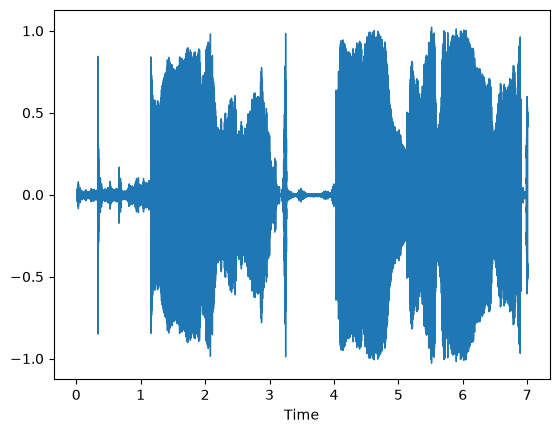

In [5]:
background_sound = "path/to/background_noise.wav"
cleaned_sounds = []
cleaned_labels = []
indicies = []  # store indicies of files that are not hungry
i = 0
vad = webrtcvad.Vad(2)
# wave_form_b, sample_rate_b = librosa.load(background_sound)  # suppose to be the background sound refrence
for folder_name, file_name in zip(label_train, data_train):
    audio_file = os.path.join("donateacry_corpus", folder_name, file_name)
    wave_form, sample_rate = librosa.load(audio_file, sr=16000)
    wave_form_new = wave_form * (2**15)
    wave_form_new = np.clip(wave_form_new, -32768, 32767).astype(np.int16)
    frame_size = 320
    frame = wave_form_new[
        0:frame_size
    ]  # to get only the first 20 milliseconds as wave form *.02 =320

    if vad.is_speech(frame, sample_rate):
        print("noise removed")
        # cleaned_sounds.append(noisereduce.reduce_noise(wave_form_b, wave_form))
        cleaned_sounds.append(wave_form)
        cleaned_labels.append(folder_name)
        if folder_name != "hungry":
            indicies.append(i)
        i += 1
    else:
        print("silence")
        continue
librosa.display.waveshow(wave_form, sr=sample_rate)

In [6]:
for i in indicies:
    audio_pretransform = cleaned_sounds[i]
    label_transform = cleaned_labels[i]
    audio_transform = librosa.effects.pitch_shift(
        audio_pretransform, sr=16000, n_steps=2
    )
    cleaned_sounds.append(audio_transform)
    cleaned_labels.append(label_transform)

    audio_transform = librosa.effects.pitch_shift(
        audio_pretransform, sr=16000, n_steps=-2
    )
    cleaned_sounds.append(audio_transform)
    cleaned_labels.append(label_transform)

    audio_transform = librosa.effects.time_stretch(audio_pretransform, rate=0.9)
    cleaned_sounds.append(audio_transform)
    cleaned_labels.append(label_transform)

    audio_transform = librosa.effects.time_stretch(audio_pretransform, rate=1.1)
    cleaned_sounds.append(audio_transform)
    cleaned_labels.append(label_transform)

    noise_strength = random.randint(100, 1000)
    noise = np.random.normal(0, noise_strength, len(audio_pretransform))
    audio_transform = audio_pretransform + noise
    cleaned_sounds.append(audio_transform)
    cleaned_labels.append(label_transform)

/home/omar/.local/lib/python3.14/site-packages/librosa/effects.py:448: FutureWarning: The `hop_length` parameter is deprecated as of 1.0 and will be removed in 1.1. It is unused in the current implementation.
  stft_stretch = core.phase_vocoder(
/home/omar/.local/lib/python3.14/site-packages/librosa/effects.py:448: FutureWarning: The `n_fft` parameter is deprecated as of 1.0 and will be removed in 1.1. It is unused in the current implementation.
  stft_stretch = core.phase_vocoder(
/home/omar/.local/lib/python3.14/site-packages/numba/np/ufunc/dufunc.py:303: RuntimeWarning: invalid value encountered in cast
  return super().__call__(*args, **kws)


In [7]:
from collections import Counter

Counter(label_train)

Counter({'hungry': 305,
         'discomfort': 22,
         'tired': 19,
         'belly_pain': 13,
         'burping': 6})